<a href="https://colab.research.google.com/github/zeynepnom/Buyuk-Veri-Analizi-Final-Odevi/blob/main/Heart_disease_risk_faktor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Heart Disease Risk Factors and Patient Health Survey Analysis***

Proje Girişi

Bu notebook, Heart_Dataset_Cleaned.csv veri seti üzerinde veri ön işleme, keşifsel veri analizi (EDA), risk faktörleri analizi ve makine öğrenmesi sınıflandırma modellerini adım adım uygulamak amacıyla hazırlanmıştır.

Gerekli Kütüphanelerin Yüklenmesi ve Veri Girişi

Analiz ve modelleme hattımızın kararlı çalışması için veri işleme (pandas, numpy), veri görselleştirme (matplotlib, seaborn) ve makine öğrenmesi (scikit-learn) kütüphanelerini çalışma ortamına dahil ediyoruz. Hemen ardından, hedef veri setini pandas DataFrame yapısına aktararak ilk analitik adımlara hazır hale getiriyoruz.

In [ ]:
# Gerekli temel kütüphanelerin yüklenmesi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Makine öğrenmesi için gerekli kütüphaneler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Görselleştirme ayarları
%matplotlib inline
sns.set_theme(style="whitegrid")

# Veri setinin yüklenmesi

try:
    df = pd.read_csv('Heart_Dataset_Cleaned.csv')
    print("Veri seti başarıyla yüklendi!")
    print(f"İlk 5 satır:\n")
    print(df.head())
except FileNotFoundError:
    print("Hata: 'Heart_Dataset_Cleaned.csv' dosyası bulunamadı. Lütfen sol menüden dosyayı Colab'e yükleyin.")

Veri seti başarıyla yüklendi!
İlk 5 satır:

    Age Gender Marital status Occupation / Daily Activities  \
0  < 35   Male         Single              Mostly Sedentary   
1  < 35   Male         Single              Mostly Sedentary   
2  < 35   Male         Single              Mostly Sedentary   
3  < 35   Male         Single              Mostly Sedentary   
4  < 35   Male        Married              Mostly Sedentary   

     Living situation Family Heart problems History Family Diabetes History  \
0  Living with family                           Yes                     Yes   
1  Living with family                            No                      No   
2  Living with family                            No                      No   
3  Living with family                            No                      No   
4  Living with family                            No                     Yes   

          Food habits          Physical activity Sleep at night  ...  \
0  Sometimes Moderate         

A)Veri Setini Tanıma ve Yapısal Analiz

Veri analizinin en kritik aşamalarından biri olan bu adımda, veri setinin genel yapısını inceleyerek kalitesini kontrol ediyoruz. Kod bloğunun çıktıları üzerinden şu hedeflere ulaşacağız:


-Boyut Analizi: Veri setinin kaç satır (gözlem) ve sütundan (öznitelik) oluştuğunun tespiti.

-Öznitelik ve Veri Tipleri: Değişken isimlerinin taranması ve kategorik/sayısal veri türü ayrımının yapılması.

-Hedef Değişken (Target) İncelemesi: Sınıflandırma modelimizin temelini oluşturacak Heart patient değişkeninin sınıfsal dengesi.

-Veri Kalite Kontrolü: Model başarısını baltalayabilecek eksik değerlerin (missing value) ve tekrarlanan mükerrer kayıtların denetimi.

In [ ]:
print("--- BÖLÜM A: VERİ SETİNİ TANIMA ---")

# 1. Satır ve sütun sayısı
satir_sayisi, sutun_sayisi = df.shape
print(f"1. Veri setinde {satir_sayisi} satır ve {sutun_sayisi} sütun vardır. ")

# 2. Değişken isimleri
print(f"\n2. Değişkenlerin isimleri:\n{list(df.columns)} ")

# 3. Kategorik ve sayısal değişkenlerin ayrımı
sayisal_degiskenler = df.select_dtypes(include=[np.number]).columns.tolist()
kategorik_degiskenler = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\n3. Sayısal Değişkenler: {sayisal_degiskenler}")
print(f"3. Kategorik Değişkenler: {kategorik_degiskenler} ")

# 4. Hedef değişken
hedef_degisken = 'Heart patient'
print(f"\n4. Hedef değişkenimiz: '{hedef_degisken}' sütunudur. [cite: 5, 8]")

# 5. Eksik değer kontrolü
eksik_degerler = df.isnull().sum().sum()
print(f"\n5. Veri setindeki toplam eksik değer sayısı: {eksik_degerler} ")
if eksik_degerler > 0:
    print(df.isnull().sum()[df.isnull().sum() > 0])

# 6. Tekrar eden kayıt kontrolü
tekrar_edenler = df.duplicated().sum()
print(f"\n6. Veri setindeki tekrar eden (mükerrer) kayıt sayısı: {tekrar_edenler} ")

--- BÖLÜM A: VERİ SETİNİ TANIMA ---
1. Veri setinde 327 satır ve 21 sütun vardır. 

2. Değişkenlerin isimleri:
['Age', 'Gender', 'Marital status', 'Occupation / Daily Activities', 'Living situation', 'Family Heart problems History', 'Family Diabetes History', 'Food habits', 'Physical activity', 'Sleep at night', 'Depression', 'Smoke or Tobacco', 'Alcohol', 'Feel stressed', 'Height (cm)', 'Weight', 'BMI', 'Blood Pressure', 'Diabetes', 'Medicines', 'Heart patient'] 

3. Sayısal Değişkenler: ['Height (cm)', 'Weight', 'BMI']
3. Kategorik Değişkenler: ['Age', 'Gender', 'Marital status', 'Occupation / Daily Activities', 'Living situation', 'Family Heart problems History', 'Family Diabetes History', 'Food habits', 'Physical activity', 'Sleep at night', 'Depression', 'Smoke or Tobacco', 'Alcohol', 'Feel stressed', 'Blood Pressure', 'Diabetes', 'Medicines', 'Heart patient'] 

4. Hedef değişkenimiz: 'Heart patient' sütunudur. [cite: 5, 8]

5. Veri setindeki toplam eksik değer sayısı: 0 

6. Veri

B)Tanımlayıcı İstatistikler ve Frekans Analizi

Bu bölümde, popülasyonun genel karakteristiklerini ve fizyolojik yapısını anlamak amacıyla verileri matematiksel olarak özetliyoruz. Bu aşamada gerçekleştireceğimiz analizler:

-Merkezi Eğilim ve Dağılım Ölçüleri: Sayısal değişkenlerin (Height, Weight, BMI) ortalama, medyan, standart sapma, minimum ve maksimum değerlerini inceleyerek kitlenin fiziksel dağılımını anlamak.

-Kategorik Frekans Sorguları: Raporda bizden spesifik olarak istenen hedef değişken (Heart patient) oranlarını ve cinsiyet dağılımlarını frekans bazlı analiz etmek.

-En Yaygın Kategorilerin (Mod) Tespiti: Popülasyon içerisinde en yüksek yoğunluğa sahip olan yaş grubunu ve kan basıncı kategorisini belirleyerek risk profilinin ağırlık merkezini bulmak.

In [ ]:
print("--- BÖLÜM B: TANIMLAYICI İSTATİSTİKLER ---")

# Sayısal değişkenler için özet istatistikler (Ortalama, medyan, std, min, max)
print("\n--- Sayısal Değişkenlerin Tanımlayıcı İstatistikleri --- [cite: 9]")
print(df.describe().T[['mean', '50%', 'std', 'min', 'max']].rename(columns={'50%': 'median'}))

# Kalp hastası sınıf dağılımı incelemesi
print("\n--- Heart Patient Sınıf Dağılımı --- [cite: 10]")
kalp_hastasi_sayisi = df['Heart patient'].value_counts()
kalp_hastasi_orani = df['Heart patient'].value_counts(normalize=True) * 100

print(f"Kalp Hastası Sayıları:\n{kalp_hastasi_sayisi} [cite: 10]")
print(f"Kalp Hastası Oranları (%):\n{kalp_hastasi_orani.round(2)} [cite: 11]")

# Cinsiyet dağılımı
print("\n--- Cinsiyet Dağılımı --- [cite: 11]")
print(df['Gender'].value_counts())

# En yaygın yaş grubu ve en yaygın kan basıncı kategorisi
print("\n--- En Yaygın Kategoriler ---")
if 'Age' in df.columns:
    print(f"En yaygın yaş grubu: {df['Age'].mode()[0]} [cite: 11]")
if 'Blood Pressure' in df.columns:
    print(f"En yaygın kan basıncı kategorisi: {df['Blood Pressure'].mode()[0]} [cite: 12]")

--- BÖLÜM B: TANIMLAYICI İSTATİSTİKLER ---

--- Sayısal Değişkenlerin Tanımlayıcı İstatistikleri --- [cite: 9]
                   mean  median        std     min     max
Height (cm)  163.072783  162.60   6.788715  137.20  182.90
Weight        67.179205   68.00  11.933481   42.00  103.00
BMI           25.237401   24.95   4.216494   16.51   42.46

--- Heart Patient Sınıf Dağılımı --- [cite: 10]
Kalp Hastası Sayıları:
Heart patient
No     219
Yes    108
Name: count, dtype: int64 [cite: 10]
Kalp Hastası Oranları (%):
Heart patient
No     66.97
Yes    33.03
Name: proportion, dtype: float64 [cite: 11]

--- Cinsiyet Dağılımı --- [cite: 11]
Gender
Male      196
Female    131
Name: count, dtype: int64

--- En Yaygın Kategoriler ---
En yaygın yaş grubu: > 50 [cite: 11]
En yaygın kan basıncı kategorisi: Normal [cite: 12]


C)Veri Görselleştirme ve Grafiksel Analiz

Bu aşamada, veri setindeki gizli örüntüleri ve eğilimleri görebilmek adına keşifsel veri analizi (EDA) sürecini görselleştiriyoruz. Tek bir matris düzeninde (3x2 subplot) çizdireceğimiz 6 farklı grafik ile şu temel ilişkileri inceleyeceğiz:

-Sınıf Dağılımı: Kalp hastası olan ve olmayan bireylerin genel popülasyondaki hacmi.

-Demografik Risk Faktörleri: Yaş grupları ve cinsiyet kırılımlarının hastalık üzerindeki etkisi.

-Antropometrik ve Klinik Göstergeler: Vücut Kitle İndeksi (BMI) dağılımı ile Kan Basıncı kategorilerinin patolojik yansımaları.

-Yaşam Tarzı Etkisi: Fiziksel aktivite sıklığının kalp sağlığı ile olan doğrudan korelasyonu.

/tmp/ipykernel_15993/3754570888.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0, 0], x='Heart patient', data=df, palette='Set2')
/tmp/ipykernel_15993/3754570888.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1, 1], x='Heart patient', y='BMI', data=df, palette='coolwarm')


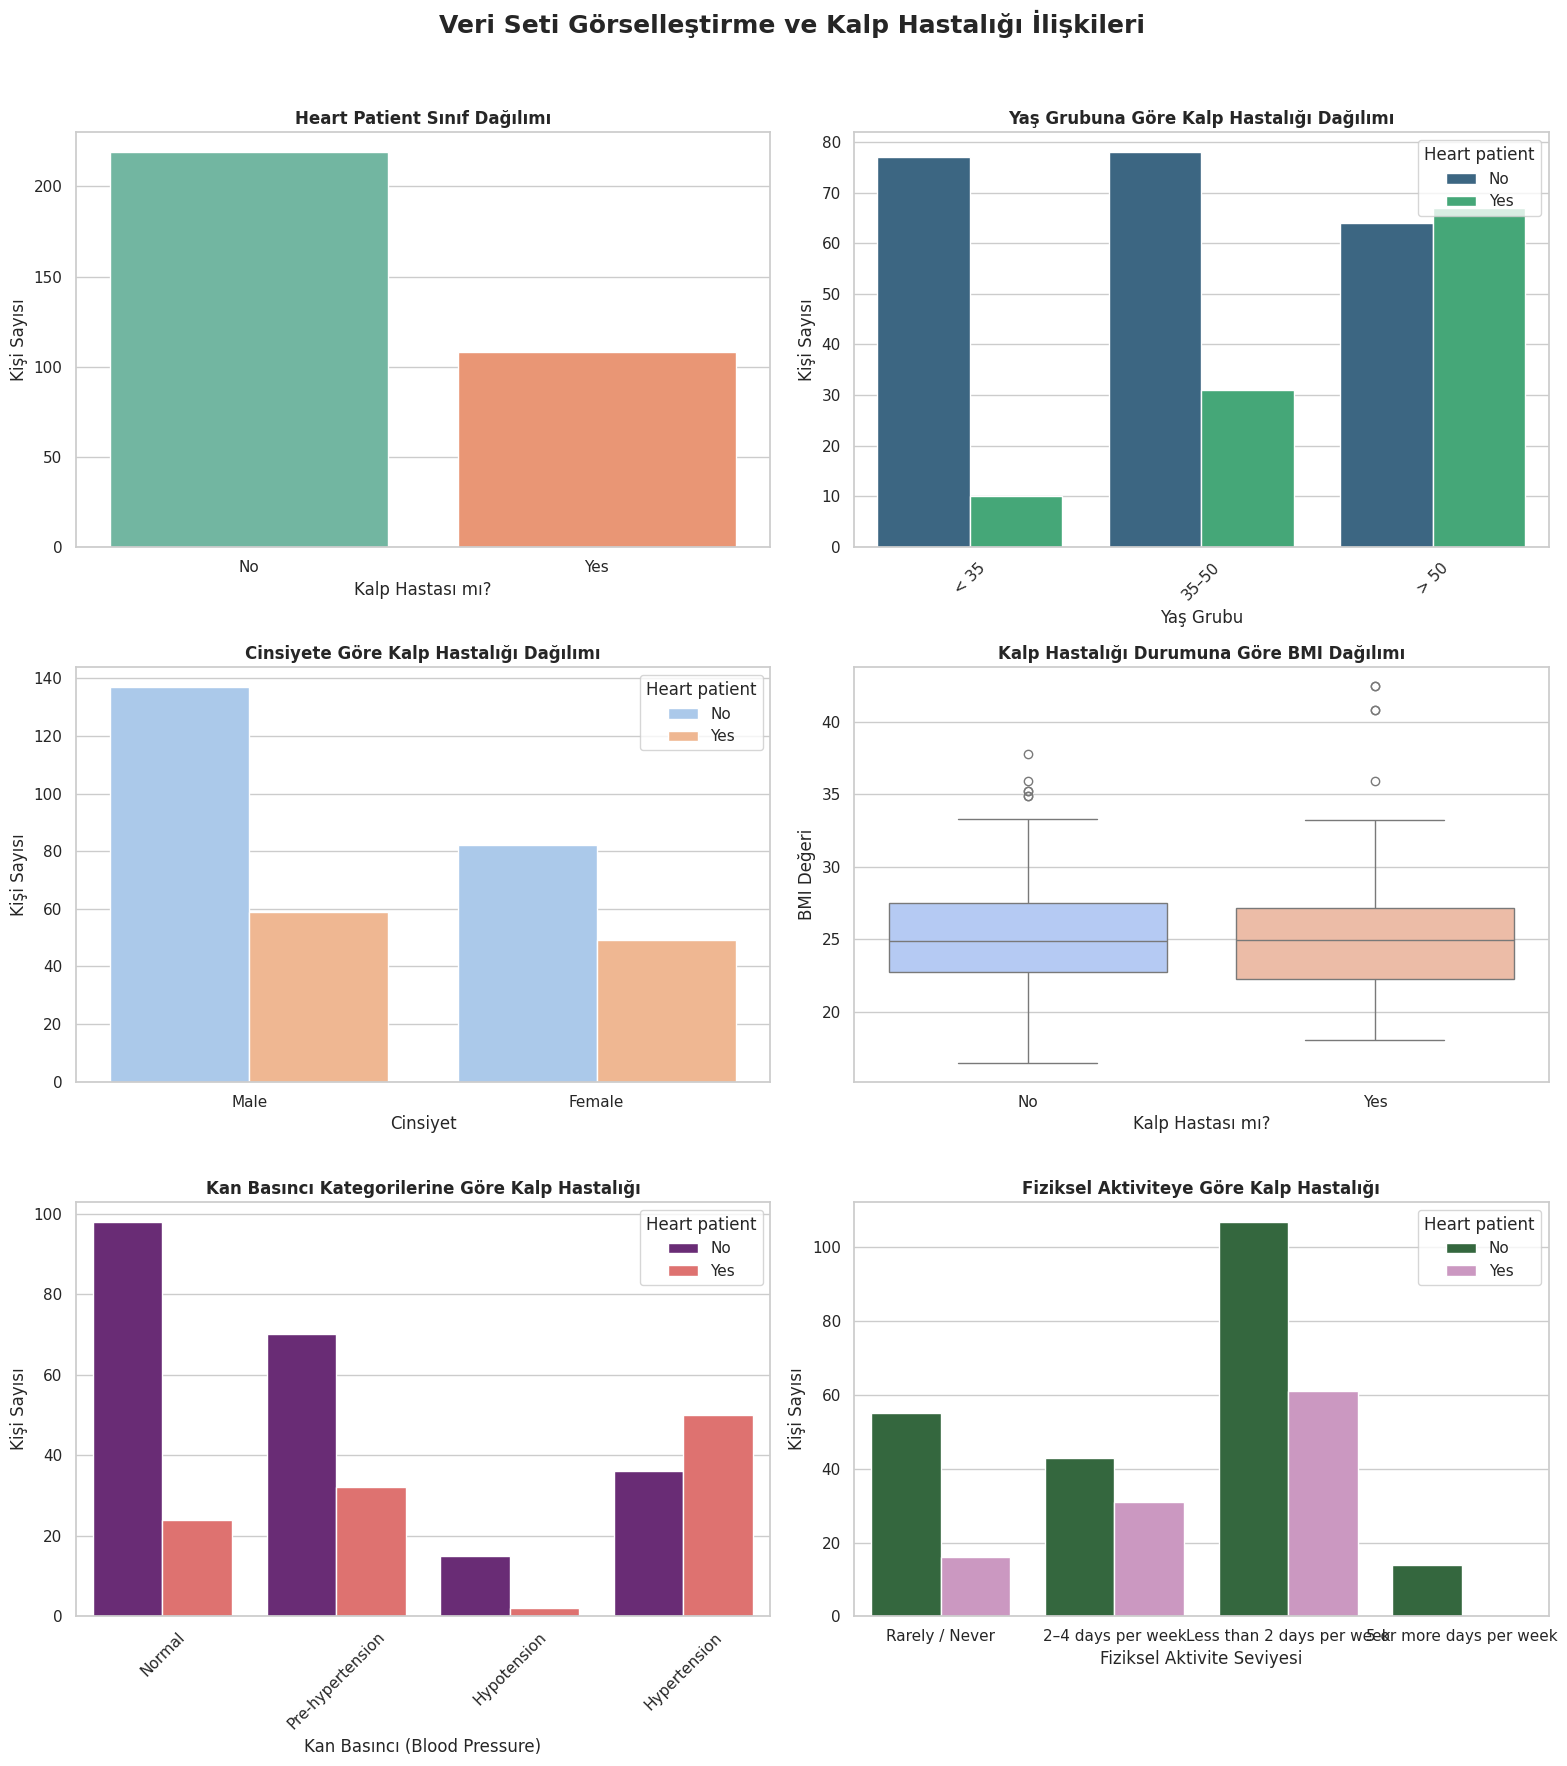

In [ ]:
# 6'lı subplot düzeni oluşturma
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Veri Seti Görselleştirme ve Kalp Hastalığı İlişkileri', fontsize=18, fontweight='bold')

# Grafi 1: Heart patient dağılımı (Bar Chart)
sns.countplot(ax=axes[0, 0], x='Heart patient', data=df, palette='Set2')
axes[0, 0].set_title('Heart Patient Sınıf Dağılımı', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Kalp Hastası mı?')
axes[0, 0].set_ylabel('Kişi Sayısı')

# Grafik 2: Yaş grubuna göre kalp hastalığı dağılımı
sns.countplot(ax=axes[0, 1], x='Age', hue='Heart patient', data=df, palette='viridis')
axes[0, 1].set_title('Yaş Grubuna Göre Kalp Hastalığı Dağılımı', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Yaş Grubu')
axes[0, 1].set_ylabel('Kişi Sayısı')
axes[0, 1].tick_params(axis='x', rotation=45)

# Grafik 3: Cinsiyete göre kalp hastalığı dağılımı
sns.countplot(ax=axes[1, 0], x='Gender', hue='Heart patient', data=df, palette='pastel')
axes[1, 0].set_title('Cinsiyete Göre Kalp Hastalığı Dağılımı', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Cinsiyet')
axes[1, 0].set_ylabel('Kişi Sayısı')

# Grafik 4: BMI dağılımı (Boxplot)
sns.boxplot(ax=axes[1, 1], x='Heart patient', y='BMI', data=df, palette='coolwarm')
axes[1, 1].set_title('Kalp Hastalığı Durumuna Göre BMI Dağılımı', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Kalp Hastası mı?')
axes[1, 1].set_ylabel('BMI Değeri')

# Grafik 5: Blood Pressure ve Heart patient ilişkisi
sns.countplot(ax=axes[2, 0], x='Blood Pressure', hue='Heart patient', data=df, palette='magma')
axes[2, 0].set_title('Kan Basıncı Kategorilerine Göre Kalp Hastalığı', fontsize=12, fontweight='bold')
axes[2, 0].set_xlabel('Kan Basıncı (Blood Pressure)')
axes[2, 0].set_ylabel('Kişi Sayısı')
axes[2, 0].tick_params(axis='x', rotation=45)

# Grafik 6: Physical activity ve Heart patient ilişkisi
sns.countplot(ax=axes[2, 1], x='Physical activity', hue='Heart patient', data=df, palette='cubehelix')
axes[2, 1].set_title('Fiziksel Aktiviteye Göre Kalp Hastalığı', fontsize=12, fontweight='bold')
axes[2, 1].set_xlabel('Fiziksel Aktivite Seviyesi')
axes[2, 1].set_ylabel('Kişi Sayısı')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

D)Risk Faktörleri Analizi (Çapraz Tablolar)

Bu bölümde, kalp hastalığı ile ilişkili olduğu bilinen 8 ana bağımsız risk faktörünü hedef değişkenimiz (Heart patient) ile çapraz tablolara (Crosstab) alarak satır bazlı yüzdesel oranlarını inceliyoruz.

Yaş, cinsiyet, kan basıncı, diyabet ve yaşam tarzı gibi kritik parametrelerin vaka oranları üzerindeki etkisini ölçeceğimiz bu adım, raporda yapacağımız tıbbi ve klinik yorumlara nesnel bir temel oluşturacaktır.

In [ ]:
print("--- BÖLÜM D: RİSK FAKTÖRLERİ ANALİZİ (ÇAPRAZ TABLOLAR) --- ")

# İncelenecek 8 ana risk faktörü listesi
risk_faktorleri = ['Age', 'Gender', 'Blood Pressure', 'Diabetes', 'Physical activity', 'Smoke or Tobacco', 'Alcohol', 'Feel stressed']

for faktor in risk_faktorleri:
    if faktor in df.columns:
        print(f"\n--- {faktor} ve Heart patient İlişkisi (Satır Yüzdesi) ---")
        ct = pd.crosstab(df[faktor], df['Heart patient'], normalize='index') * 100
        print(ct.round(2))

--- BÖLÜM D: RİSK FAKTÖRLERİ ANALİZİ (ÇAPRAZ TABLOLAR) --- 

--- Age ve Heart patient İlişkisi (Satır Yüzdesi) ---
Heart patient     No    Yes
Age                        
35–50          71.56  28.44
< 35           88.51  11.49
> 50           48.85  51.15

--- Gender ve Heart patient İlişkisi (Satır Yüzdesi) ---
Heart patient    No   Yes
Gender                   
Female         62.6  37.4
Male           69.9  30.1

--- Blood Pressure ve Heart patient İlişkisi (Satır Yüzdesi) ---
Heart patient        No    Yes
Blood Pressure                
Hypertension      41.86  58.14
Hypotension       88.24  11.76
Normal            80.33  19.67
Pre-hypertension  68.63  31.37

--- Diabetes ve Heart patient İlişkisi (Satır Yüzdesi) ---
Heart patient     No    Yes
Diabetes                   
Diabetes       58.82  41.18
Normal         78.10  21.90
Prediabetes    59.09  40.91

--- Physical activity ve Heart patient İlişkisi (Satır Yüzdesi) ---
Heart patient                  No    Yes
Physical activity    

E)Makine Öğrenmesi Modelleri ve Performans Değerlendirmesi

Bu bölümde, hazırlanan veri altyapısı üzerinde kalp hastalığı varlığını tahmin edecek sınıflandırma modellerini inşa ediyor ve eğitiyoruz. Kod bloğu sırasıyla şu adımları gerçekleştirmektedir:

-Öznitelik Dönüşümü (Encoding): Algoritmaların matematiksel olarak işleyebilmesi için metinsel kategorik değişkenleri LabelEncoder kullanarak sayısal formata getirmek.

-Veri Ayrıştırma (Train-Test Split): Modellerin genelleme yeteneğini nesnel ölçebilmek adına veri setini %80 Eğitim ve %20 Test kümesi olarak bölmek. Sınıf dengesini korumak için stratify=y parametresini uygulamak.

-Model Eğitimi: Doğrusal tabanlı Lojistik Regresyon (Logistic Regression) ve toplu öğrenme tabanlı Rastgele Orman (Random Forest) algoritmalarını eğitmek.

-Metrik Ölçümü: Sınıflandırma başarılarını karmaşıklık matrisi (Confusion Matrix) ile birlikte Doğruluk, Kesinlik, Duyarlılık ve F1-Skor metrikleri üzerinden hesaplamak.

In [ ]:
print("--- BÖLÜM E: MAKİNE ÖĞRENMESİ MODELLERİ --- [cite: 18]")

# 1. Verinin kopyasını oluşturma ve Kategorik Değişkenlerin Sayısallaştırılması
df_model = df.copy()
le = LabelEncoder()

for col in df_model.select_dtypes(include=['object', 'category']).columns:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Bağımsız değişkenler (X) ve Hedef Değişken (y) ayrımı
X = df_model.drop(columns=['Heart patient'])
y = df_model['Heart patient']

# 2. Tren-Test Ayrımı (%80 Train, %20 Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(f"Eğitim Seti Boyutu: {X_train.shape}, Test Seti Boyutu: {X_test.shape} [cite: 20]")

# 3. Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# Model 2: Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# 4. Performans Karşılaştırma Fonksiyonu
def model_performans_raporu(y_true, y_pred, model_adi):
    print(f"\n================ {model_adi} Performansı ================")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f} [cite: 21]")
    print(f"Precision: {precision_score(y_true, y_pred):.4f} [cite: 21]")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f} [cite: 21]")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f} [cite: 21]")
    print("\nConfusion Matrix: [cite: 21]")
    print(confusion_matrix(y_true, y_pred))

# Performans sonuçlarını yazdırma
model_performans_raporu(y_test, lr_preds, "Logistic Regression [cite: 19]")
model_performans_raporu(y_test, rf_preds, "Random Forest [cite: 19]")

# 5. Öznitelik Önem Düzeyleri (Random Forest için En Önemli Değişkenler)
print("\n================ Random Forest Değişken Önem Dereceleri ================")
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
for f in range(X.shape[1]):
    print(f"{f + 1}. Değişken: {X.columns[indices[f]]} ({importances[indices[f]]:.4f}) [cite: 24]")

--- BÖLÜM E: MAKİNE ÖĞRENMESİ MODELLERİ --- [cite: 18]
Eğitim Seti Boyutu: (261, 20), Test Seti Boyutu: (66, 20) [cite: 20]

================ Logistic Regression [cite: 19] Performansı ================
Accuracy:  0.7727 [cite: 21]
Precision: 0.8182 [cite: 21]
Recall:    0.4091 [cite: 21]
F1-Score:  0.5455 [cite: 21]

Confusion Matrix: [cite: 21]
[[42  2]
 [13  9]]

================ Random Forest [cite: 19] Performansı ================
Accuracy:  0.7424 [cite: 21]
Precision: 0.7273 [cite: 21]
Recall:    0.3636 [cite: 21]
F1-Score:  0.4848 [cite: 21]

Confusion Matrix: [cite: 21]
[[41  3]
 [14  8]]

================ Random Forest Değişken Önem Dereceleri ================
1. Değişken: BMI (0.1128) [cite: 24]
2. Değişken: Height (cm) (0.0972) [cite: 24]
3. Değişken: Weight (0.0967) [cite: 24]
4. Değişken: Blood Pressure (0.0917) [cite: 24]
5. Değişken: Age (0.0709) [cite: 24]
6. Değişken: Marital status (0.0566) [cite: 24]
7. Değişken: Occupation / Daily Activities (0.0491) [cite: 24]
8. D

### ROC Eğrisi ve AUC Skoru

Model performansını daha detaylı değerlendirmek için ROC (Receiver Operating Characteristic) eğrisini çizdirip, AUC (Area Under the Curve) skorunu hesaplayacağız. ROC eğrisi, bir sınıflandırıcının farklı sınıflandırma eşiklerinde hassasiyet (true positive rate) ve özgüllük (false positive rate) arasındaki değişimi gösterir. AUC değeri ise modelin tüm eşiklerdeki genel performansını özetler; 1'e yakın değerler daha iyi bir sınıflandırma performansı anlamına gelir.

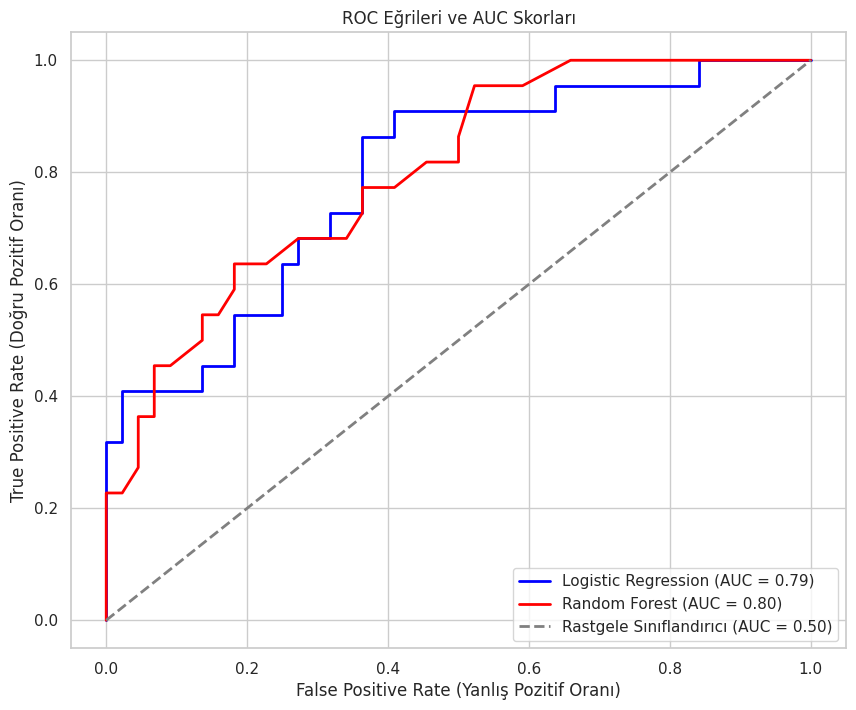

In [ ]:
from sklearn.metrics import roc_curve, auc

# Logistic Regression için ROC ve AUC hesaplama
lr_probs = lr_model.predict_proba(X_test)[:, 1]
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
lr_auc = auc(lr_fpr, lr_tpr)

# Random Forest için ROC ve AUC hesaplama
rf_probs = rf_model.predict_proba(X_test)[:, 1]
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
rf_auc = auc(rf_fpr, rf_tpr)

# ROC eğrilerini çizdirme
plt.figure(figsize=(10, 8))
plt.plot(lr_fpr, lr_tpr, color='blue', lw=2, label=f'Logistic Regression (AUC = {lr_auc:.2f})')
plt.plot(rf_fpr, rf_tpr, color='red', lw=2, label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Rastgele Sınıflandırıcı (AUC = 0.50)')
plt.xlabel('False Positive Rate (Yanlış Pozitif Oranı)')
plt.ylabel('True Positive Rate (Doğru Pozitif Oranı)')
plt.title('ROC Eğrileri ve AUC Skorları')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()